### Analisis de cambio de bosques a usos agrícolas
Objetivo: analizar la conversión de bosques a agricultura en el Chaco Seco a partir de mapas de cobertura.
#### Hipótesis:
Existe una intensificación del cambio de uso del suelo respecto a periodos anteriores, asociada principalmente a la expansión del agronegocio.


In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
print("librerias ok")
# Directorio de trabajo
os.chdir("D:/Josefina/Proyectos/Bosques/data/cobertura_CS")


librerias ok


In [2]:


# ---------------------------------------------------------
# Lectura de rasters de cobertura
# ---------------------------------------------------------

with rasterio.open("cobertura_2003_CS.tif") as src:
    r2000 = src.read(1)
    profile = src.profile

with rasterio.open("cobertura_2004_CS.tif") as src:
    r2001 = src.read(1)

for i in range(1):

    # ---------------------------------------------------------
    # Definición de clases de cobertura
    # ---------------------------------------------------------
    # IDs correspondientes a bosque nativo

    bosque_ids = [3, 4, 6, 66, 77, 63]

    # Otros IDs posibles (no utilizados en este bloque)
    # agro_ids = [19, 36, 15, 9]
    # urbano_ids = [24]
    # no_veg_ids = [25]
    # agua_ids = [33, 34]
    # herbaceas_ids = [12, 11, 73]
    # Mosaico_usos = [21]
    # agricultura = [18]

    agro_ids = [19, 36, 15, 9]  # necesario para el cálculo

    no_obs = [27]

    # ---------------------------------------------------------
    # Identificación de cambio bosque → agricultura
    # ---------------------------------------------------------
    # Si un píxel es bosque en t0 y agricultura en t1
    # se considera cambio de uso del suelo.

    # Pixel = 30 m → 900 m2

    cambio = np.isin(r2000, bosque_ids) & np.isin(r2001, agro_ids)

    # raster binario de cambio
    cambio_bin = np.where(cambio, 1, np.nan)

    # ---------------------------------------------------------
    # Cálculo de superficie convertida
    # ---------------------------------------------------------

    area_m2 = np.nansum(cambio_bin) * 900

    # conversión a hectáreas
    area_cambio = area_m2 / 10000

    print(area_cambio)


73800.45


In [3]:
# Superficie total del área de estudio

n_pixeles = r2000.size
area_total_m2 = n_pixeles * 900

area_total_ha = area_total_m2 / 10000
area_total_km2 = area_total_m2 / 1e6

# porcentaje del área total convertida
print((area_cambio / area_total_ha) * 100)


0.43571740858970187


In [6]:
# Datos de cambio anual bosque → agricultura
df = pd.DataFrame({
    "periodo": [2000,2001,2002,2003,2004,2005,2006],#,2007,2008,2009],
    "ha_diferencia": [
        54925,66171.24,75904.65,73800.45,66103.65,
        53456.58,41613.93
    ]
})


In [8]:
# ---------------------------------------------------------
# Estimación de cobertura de bosque en un año

bosque_ids = [3, 4, 6, 66, 77, 63]

with rasterio.open("cobertura_2003_CS.tif") as src:
    r2024 = src.read(1)

# máscara de bosque
bosque_2024 = np.where(np.isin(r2024, bosque_ids), 1, np.nan)

# contar píxeles de bosque
n_pixeles_bosque = np.nansum(bosque_2024)

# conversión a hectáreas
area_bosque_ha = n_pixeles_bosque * 0.09

# en km2
area_bosque_km2 = area_bosque_ha / 100

print(area_bosque_ha)
print(area_bosque_km2)




3690557.73
36905.5773


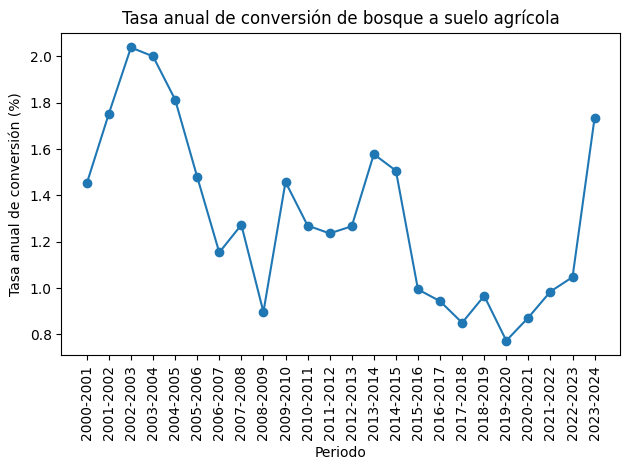

In [9]:
###################
# Construcción del dataframe de deforestación
###################

deforestacion = pd.DataFrame({

    "Periodo": [
        "2000-2001","2001-2002","2002-2003","2003-2004","2004-2005",
        "2005-2006","2006-2007","2007-2008","2008-2009","2009-2010",
        "2010-2011","2011-2012","2012-2013","2013-2014","2014-2015",
        "2015-2016","2016-2017","2017-2018","2018-2019","2019-2020",
        "2020-2021","2021-2022","2022-2023","2023-2024","2024"
    ],

    "ha_diferencia_bosque_a_agro": [
        54925, 66171.24, 75904.65, 73800.45, 66103.65,
        53456.58, 41613.93, 45796.5, 31958, 51932.52,
        45273.6, 43959.69, 45032.4, 56015.28, 53313.84,
        35083.53, 33146.55, 29752.92, 33610.41, 26846.01,
        30604.41, 34756.83, 36789.12, 60153.93, 0
    ],

    "cobertura_bosque_inicial_ha": [
        3783505, 3775279, 3724620, 3690558, 3645118,
        3612188, 3606359, 3597749, 3562450, 3561906,
        3565171, 3556384, 3554908, 3550256, 3538632,
        3528318, 3512542, 3498028, 3477117, 3471616,
        3504935, 3527330, 3512248, 3467283, 3364088
    ]
})

# ---------------------------------------------------------
# Cálculo de tasa anual de deforestación


deforestacion_plot = deforestacion.copy()

deforestacion_plot["tasa_porcentual_anual"] = (
    deforestacion_plot["ha_diferencia_bosque_a_agro"] /
    deforestacion_plot["cobertura_bosque_inicial_ha"]
) * 100

deforestacion_plot = deforestacion_plot[
    deforestacion_plot["Periodo"] != "2024"
]

# ---------------------------------------------------------
# Gráfico de tasa anual de conversión


plt.figure()
plt.plot(deforestacion_plot["Periodo"],
         deforestacion_plot["tasa_porcentual_anual"])
plt.scatter(deforestacion_plot["Periodo"],
            deforestacion_plot["tasa_porcentual_anual"])

plt.title("Tasa anual de conversión de bosque a suelo agrícola")
plt.xlabel("Periodo")
plt.ylabel("Tasa anual de conversión (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()